  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/71.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/25.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/37 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['patient', 'image', 'instances', 'tissue'],
        num_rows: 37
    })
    test: Dataset({
        features: ['patient', 'image', 'instances', 'tissue'],
        num_rows: 14
    })
})
Train size: 37
Test size : 14


Exporting test: 100%|██████████| 14/14 [00:18<00:00,  1.35s/it]



PNG export complete
Saved image/mask pairs: 51
Skipped empty samples : 0
Image count: 51
Mask  count: 51



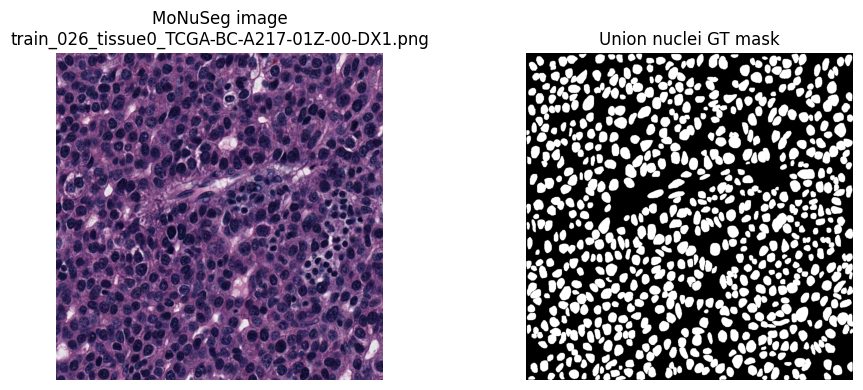

Sample file: train_026_tissue0_TCGA-BC-A217-01Z-00-DX1.png  Mask pixels: 394008
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


Quick SAM test: 100%|██████████| 20/20 [00:04<00:00,  4.39it/s]



Quick test summary:
            dice        iou
count  20.000000  20.000000
mean    0.347659   0.212338
std     0.068437   0.049219
min     0.186073   0.102580
25%     0.293808   0.172207
50%     0.362633   0.221478
75%     0.392234   0.243962
max     0.463163   0.301374


Full SAM evaluation: 100%|██████████| 51/51 [00:08<00:00,  6.15it/s]



Saved: /content/monuseg_sam_project/monuseg_sam_boxprompt_metrics.csv
            dice        iou
count  51.000000  51.000000
mean    0.395921   0.253151
std     0.114636   0.090575
min     0.186073   0.102580
25%     0.317045   0.188463
50%     0.387604   0.240390
75%     0.495126   0.329015
max     0.598091   0.426626

Failure rate (Dice < 0.5): 78.43 %
Severe failure (Dice < 0.1): 0.0 %

Worst 10 images:
                                             file      dice       iou
6    test_006_tissue0_TCGA-HT-8564-01Z-00-DX1.png  0.186073  0.102580
35  train_021_tissue2_TCGA-B0-5710-01Z-00-DX1.png  0.212723  0.119021
37  train_023_tissue2_TCGA-B0-5711-01Z-00-DX1.png  0.213726  0.119649
48  train_034_tissue2_TCGA-B0-5698-01Z-00-DX1.png  0.223837  0.126023
27  train_013_tissue1_TCGA-E2-A1B5-01Z-00-DX1.png  0.226183  0.127512
33  train_019_tissue3_TCGA-21-5784-01Z-00-DX1.png  0.242004  0.137659
22  train_008_tissue5_TCGA-G2-A2EK-01A-02-TSB.png  0.242592  0.138039
18  train_004_tissue2_TCGA-H

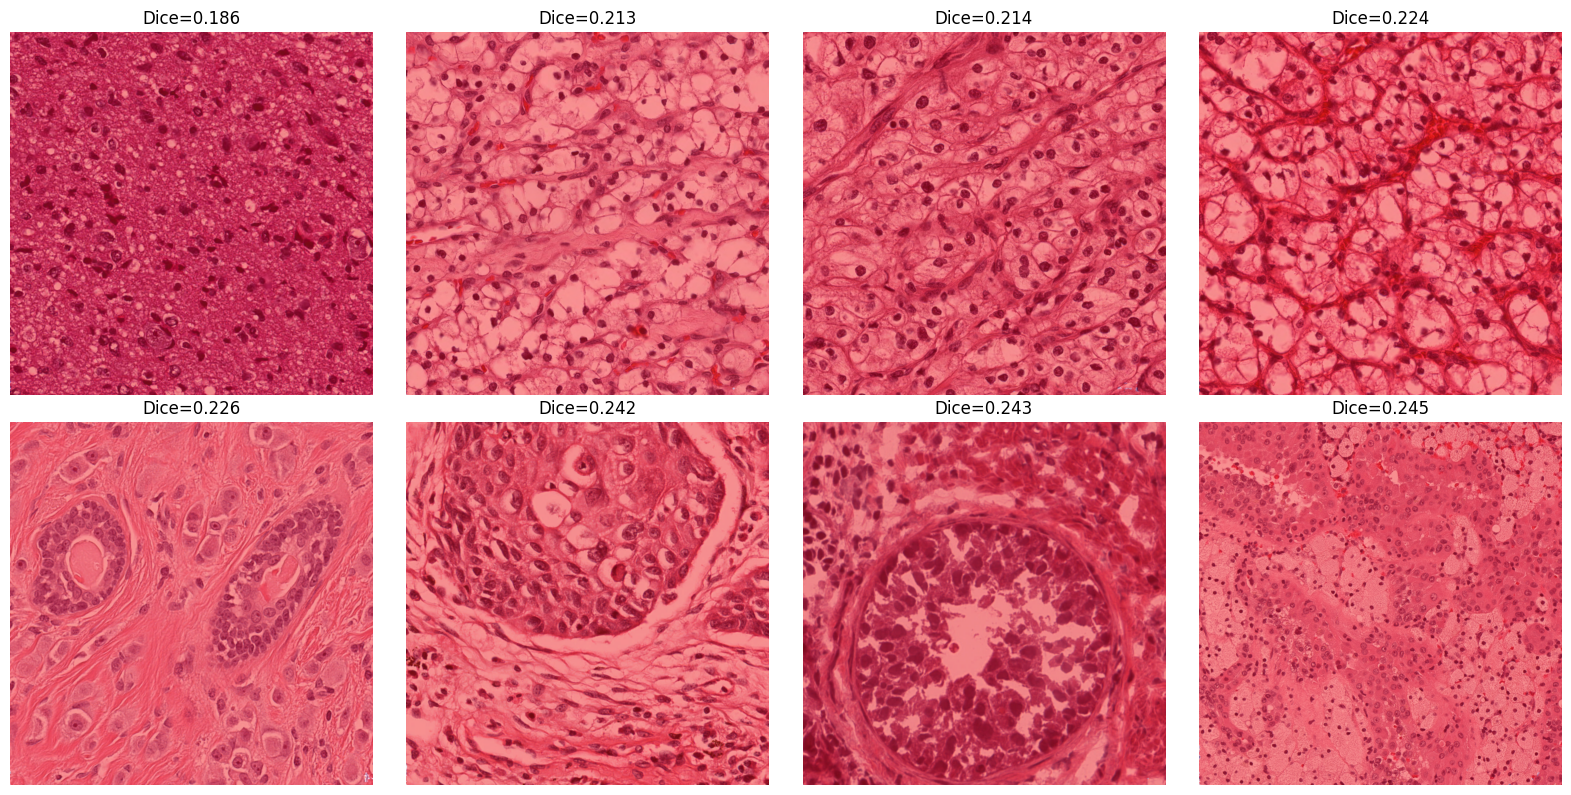

Saved: /content/monuseg_sam_project/monuseg_worst_cases_overlay.png


Robustness evaluation: 100%|██████████| 51/51 [01:23<00:00,  1.63s/it]



Saved: /content/monuseg_sam_project/monuseg_sam_robustness_results.csv

Robustness summary:
        condition  mean_dice  mean_iou  mean_delta_dice  mean_delta_iou  \
5    down_up_0.25   0.395877  0.253114    -4.351926e-05   -3.651785e-05   
10  noise_sigma25   0.395889  0.253123    -3.240390e-05   -2.789268e-05   
1         blur_k7   0.395899  0.253133    -2.209661e-05   -1.770260e-05   
6     down_up_0.5   0.395909  0.253141    -1.167961e-05   -9.625890e-06   
8       gamma_1.2   0.395914  0.253145    -6.667579e-06   -5.529031e-06   
0         blur_k3   0.395916  0.253146    -4.552315e-06   -4.583535e-06   
9   noise_sigma10   0.395920  0.253148    -9.064422e-07   -2.417973e-06   
3    contrast_0.8   0.395920  0.253150    -6.986971e-07   -5.621647e-07   
2           clean   0.395921  0.253151     0.000000e+00    0.000000e+00   
7       gamma_0.8   0.395926  0.253155     4.802129e-06    4.039699e-06   
4    contrast_1.2   0.395939  0.253166     1.852668e-05    1.496536e-05   

    fa

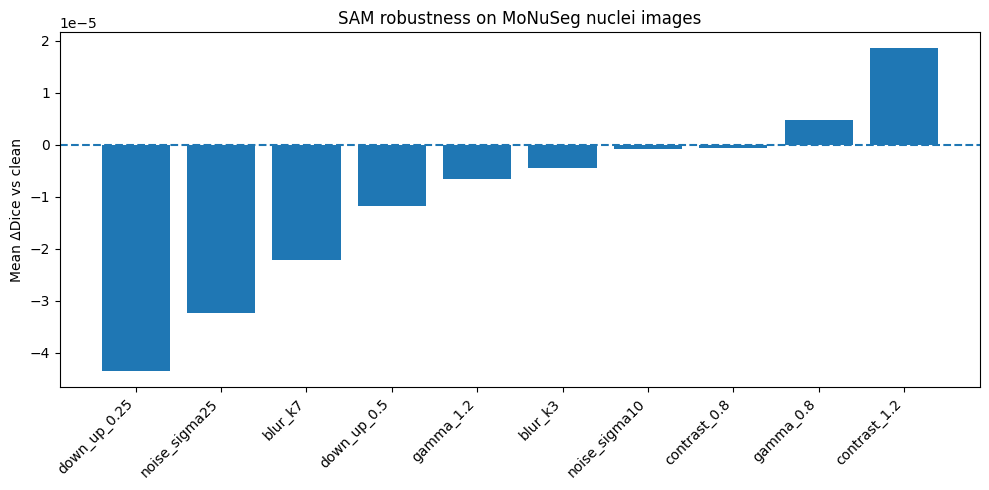

Saved: /content/monuseg_sam_project/monuseg_robustness_barplot.png
Saved: /content/monuseg_sam_project/monuseg_summary.txt

✅ ALL DONE
Main output folder: /content/monuseg_sam_project
Files inside:
 - images
 - masks
 - monuseg_robustness_barplot.png
 - monuseg_robustness_summary_table.csv
 - monuseg_sam_boxprompt_metrics.csv
 - monuseg_sam_robustness_results.csv
 - monuseg_summary.txt
 - monuseg_worst_cases_overlay.png
 - preds

ZIP ready at: /content/monuseg_sam_outputs.zip


In [1]:
# ============================================================
# SAM ROBUSTNESS PIPELINE FOR HISTOPATHOLOGY (MoNuSeg)
# Colab-ready | No Google Drive usage
# Uses Hugging Face dataset: RationAI/MoNuSeg
# Binary nuclei segmentation from union of instance masks
# ============================================================

# -----------------------------
# 0) Install dependencies
# -----------------------------
!pip -q install datasets pillow opencv-python matplotlib pandas tqdm
!pip -q install git+https://github.com/facebookresearch/segment-anything.git

# -----------------------------
# 1) Download SAM checkpoint
# -----------------------------
!wget -q -O /content/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# -----------------------------
# 2) Imports
# -----------------------------
import os
import random
import zipfile
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
from datasets import load_dataset
from segment_anything import sam_model_registry, SamPredictor

# -----------------------------
# 3) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# 4) Output folders
# -----------------------------
OUT_ROOT = "/content/monuseg_sam_project"
IMG_DIR = os.path.join(OUT_ROOT, "images")
MSK_DIR = os.path.join(OUT_ROOT, "masks")
PRED_DIR = os.path.join(OUT_ROOT, "preds")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MSK_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# -----------------------------
# 5) Load MoNuSeg dataset
# -----------------------------
# If this prompts a retry once due to network, rerun the cell.
ds = load_dataset("RationAI/MoNuSeg")

print(ds)
print("Train size:", len(ds["train"]))
print("Test size :", len(ds["test"]))

# -----------------------------
# 6) Helper functions
# -----------------------------
def pil_to_rgb_np(img):
    if isinstance(img, Image.Image):
        return np.array(img.convert("RGB"))
    return np.array(img)

def instance_list_to_union_mask(instances):
    """
    instances: list of binary instance masks
    returns single binary union mask (uint8, 0/255)
    """
    if len(instances) == 0:
        return None

    union = None
    for inst in instances:
        arr = np.array(inst)
        if arr.ndim == 3:
            arr = arr[..., 0]
        arr = (arr > 0).astype(np.uint8)

        if union is None:
            union = arr.copy()
        else:
            union = np.maximum(union, arr)

    return (union > 0).astype(np.uint8) * 255

def mask_to_box(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.int32)

def dice_iou(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)

    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    dice = (2.0 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)

def overlay_mask(img_rgb, mask, color=(255, 0, 0), alpha=0.4):
    out = img_rgb.copy().astype(np.float32)
    m = mask > 0
    color_arr = np.array(color, dtype=np.float32)
    out[m] = (1 - alpha) * out[m] + alpha * color_arr
    return np.clip(out, 0, 255).astype(np.uint8)

# perturbations
def add_gaussian_noise(img, sigma):
    x = img.astype(np.float32)
    n = np.random.normal(0, sigma, x.shape).astype(np.float32)
    y = np.clip(x + n, 0, 255)
    return y.astype(np.uint8)

def gaussian_blur(img, k):
    return cv2.GaussianBlur(img, (k, k), 0)

def down_up(img, scale):
    h, w = img.shape[:2]
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    small = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    back = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    return back

def contrast_scale(img, a):
    x = img.astype(np.float32) * a
    return np.clip(x, 0, 255).astype(np.uint8)

def gamma_corr(img, gamma):
    x = img.astype(np.float32) / 255.0
    y = np.power(x, gamma)
    return np.clip(y * 255.0, 0, 255).astype(np.uint8)

# -----------------------------
# 7) Export train+test images and union masks as PNGs
# -----------------------------
saved = 0
skipped_empty = 0

for split_name in ["train", "test"]:
    split = ds[split_name]

    for i in tqdm(range(len(split)), desc=f"Exporting {split_name}"):
        row = split[i]

        img = pil_to_rgb_np(row["image"])
        instances = row["instances"]

        union_mask = instance_list_to_union_mask(instances)
        if union_mask is None or union_mask.sum() == 0:
            skipped_empty += 1
            continue

        patient = str(row.get("patient", f"{split_name}_{i}"))
        tissue = str(row.get("tissue", "unknown"))

        fname = f"{split_name}_{i:03d}_tissue{tissue}_{patient}.png"
        fname = fname.replace("/", "_").replace(" ", "_")

        cv2.imwrite(os.path.join(IMG_DIR, fname), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(MSK_DIR, fname), union_mask)
        saved += 1

print("\n====================")
print("PNG export complete")
print("Saved image/mask pairs:", saved)
print("Skipped empty samples :", skipped_empty)
print("Image count:", len(os.listdir(IMG_DIR)))
print("Mask  count:", len(os.listdir(MSK_DIR)))
print("====================\n")

# -----------------------------
# 8) Visual sanity check
# -----------------------------
png_files = sorted(os.listdir(IMG_DIR))
assert len(png_files) > 0, "No PNG files created."

sample_file = random.choice(png_files)
sample_img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, sample_file)), cv2.COLOR_BGR2RGB)
sample_msk = cv2.imread(os.path.join(MSK_DIR, sample_file), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title(f"MoNuSeg image\n{sample_file}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_msk, cmap="gray")
plt.title("Union nuclei GT mask")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample file:", sample_file, " Mask pixels:", int((sample_msk > 0).sum()))

# -----------------------------
# 9) Load SAM
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

# -----------------------------
# 10) Quick test on first 20 images
# -----------------------------
quick_files = png_files[:20]
quick_rows = []

for f in tqdm(quick_files, desc="Quick SAM test"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    predictor.set_image(img)
    masks, scores, logits = predictor.predict(
        box=box,
        multimask_output=True
    )
    pred = masks[np.argmax(scores)]

    d, j = dice_iou(pred, gt)
    quick_rows.append({"file": f, "dice": d, "iou": j})

quick_df = pd.DataFrame(quick_rows)
print("\nQuick test summary:")
print(quick_df[["dice", "iou"]].describe())

# -----------------------------
# 11) Full SAM evaluation
# -----------------------------
rows = []

for f in tqdm(png_files, desc="Full SAM evaluation"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    predictor.set_image(img)
    masks, scores, logits = predictor.predict(
        box=box,
        multimask_output=True
    )
    pred = masks[np.argmax(scores)].astype(np.uint8)

    d, j = dice_iou(pred, gt)
    rows.append({"file": f, "dice": d, "iou": j})

    cv2.imwrite(os.path.join(PRED_DIR, f), pred * 255)

metrics_df = pd.DataFrame(rows)
metrics_csv = os.path.join(OUT_ROOT, "monuseg_sam_boxprompt_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

print("\nSaved:", metrics_csv)
print(metrics_df[["dice", "iou"]].describe())

fail_05 = (metrics_df["dice"] < 0.5).mean()
fail_01 = (metrics_df["dice"] < 0.1).mean()
print("\nFailure rate (Dice < 0.5):", round(fail_05 * 100, 2), "%")
print("Severe failure (Dice < 0.1):", round(fail_01 * 100, 2), "%")

print("\nWorst 10 images:")
print(metrics_df.sort_values("dice").head(10))

# -----------------------------
# 12) Worst-case overlay figure
# -----------------------------
worst_df = metrics_df.sort_values("dice").head(8)

plt.figure(figsize=(16, 8))
for idx, row in enumerate(worst_df.itertuples(), 1):
    f = row.file
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    predictor.set_image(img)
    masks, scores, logits = predictor.predict(box=box, multimask_output=True)
    pred = masks[np.argmax(scores)].astype(np.uint8)

    overlay = overlay_mask(img, pred, color=(255, 0, 0), alpha=0.4)

    plt.subplot(2, 4, idx)
    plt.imshow(overlay)
    plt.title(f"Dice={row.dice:.3f}")
    plt.axis("off")

plt.tight_layout()
worst_fig = os.path.join(OUT_ROOT, "monuseg_worst_cases_overlay.png")
plt.savefig(worst_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", worst_fig)

# -----------------------------
# 13) Robustness evaluation
# -----------------------------
settings = [
    ("clean", None),
    ("noise_sigma10", ("noise", 10)),
    ("noise_sigma25", ("noise", 25)),
    ("blur_k3", ("blur", 3)),
    ("blur_k7", ("blur", 7)),
    ("down_up_0.5", ("downup", 0.5)),
    ("down_up_0.25", ("downup", 0.25)),
    ("contrast_0.8", ("contrast", 0.8)),
    ("contrast_1.2", ("contrast", 1.2)),
    ("gamma_0.8", ("gamma", 0.8)),
    ("gamma_1.2", ("gamma", 1.2)),
]

rob_rows = []

for f in tqdm(png_files, desc="Robustness evaluation"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    for tag, spec in settings:
        if spec is None:
            x = img.copy()
        else:
            kind, val = spec
            if kind == "noise":
                x = add_gaussian_noise(img, val)
            elif kind == "blur":
                x = gaussian_blur(img, val)
            elif kind == "downup":
                x = down_up(img, val)
            elif kind == "contrast":
                x = contrast_scale(img, val)
            elif kind == "gamma":
                x = gamma_corr(img, val)
            else:
                x = img.copy()

        predictor.set_image(x)
        masks, scores, logits = predictor.predict(
            box=box,
            multimask_output=True
        )
        pred = masks[np.argmax(scores)]

        d, j = dice_iou(pred, gt)
        rob_rows.append({
            "file": f,
            "condition": tag,
            "dice": d,
            "iou": j
        })

rob_df = pd.DataFrame(rob_rows)
rob_csv = os.path.join(OUT_ROOT, "monuseg_sam_robustness_results.csv")
rob_df.to_csv(rob_csv, index=False)
print("\nSaved:", rob_csv)

# -----------------------------
# 14) Robustness summary
# -----------------------------
base = rob_df[rob_df["condition"] == "clean"][["file", "dice", "iou"]].rename(
    columns={"dice": "dice_clean", "iou": "iou_clean"}
)

merged = rob_df.merge(base, on="file", how="left")
merged["delta_dice"] = merged["dice"] - merged["dice_clean"]
merged["delta_iou"] = merged["iou"] - merged["iou_clean"]

summary = merged.groupby("condition").agg(
    mean_dice=("dice", "mean"),
    mean_iou=("iou", "mean"),
    mean_delta_dice=("delta_dice", "mean"),
    mean_delta_iou=("delta_iou", "mean"),
    failure_rate_05=("dice", lambda s: (s < 0.5).mean())
).reset_index().sort_values("mean_delta_dice")

summary_csv = os.path.join(OUT_ROOT, "monuseg_robustness_summary_table.csv")
summary.to_csv(summary_csv, index=False)

print("\nRobustness summary:")
print(summary)
print("\nSaved:", summary_csv)

# -----------------------------
# 15) Robustness bar plot
# -----------------------------
plot_df = summary.copy()
plot_df = plot_df[plot_df["condition"] != "clean"]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["condition"], plot_df["mean_delta_dice"])
plt.axhline(0, linestyle="--")
plt.ylabel("Mean ΔDice vs clean")
plt.title("SAM robustness on MoNuSeg nuclei images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = os.path.join(OUT_ROOT, "monuseg_robustness_barplot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

# -----------------------------
# 16) Save quick text summary
# -----------------------------
summary_txt = os.path.join(OUT_ROOT, "monuseg_summary.txt")
with open(summary_txt, "w") as f:
    f.write("MoNuSeg SAM robustness study\n")
    f.write("===========================\n")
    f.write(f"Images evaluated: {len(metrics_df)}\n")
    f.write(f"Mean Dice: {metrics_df['dice'].mean():.4f}\n")
    f.write(f"Mean IoU : {metrics_df['iou'].mean():.4f}\n")
    f.write(f"Failure rate Dice<0.5: {(metrics_df['dice'] < 0.5).mean() * 100:.2f}%\n")
    f.write(f"Severe failure Dice<0.1: {(metrics_df['dice'] < 0.1).mean() * 100:.2f}%\n")

print("Saved:", summary_txt)

# -----------------------------
# 17) Zip outputs
# -----------------------------
!cd /content && zip -rq monuseg_sam_outputs.zip monuseg_sam_project

print("\n✅ ALL DONE")
print("Main output folder:", OUT_ROOT)
print("Files inside:")
for x in sorted(os.listdir(OUT_ROOT)):
    print(" -", x)

print("\nZIP ready at: /content/monuseg_sam_outputs.zip")

In [2]:
from google.colab import files
files.download("/content/monuseg_sam_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>